📐 Конфигурация Bowtie:
   • d_small       = 128 (1/4 от 512)
   • n_layers      = 26 (2 big + 24 small)
   • Эффективная глубина ≈ 3.5 больших слоёв
   • ~11.0M параметров в трансформер-блоках

📊 Standard: 76.74M параметров | 8 слоёв
📊 Bowtie:   63.11M параметров | 26 слоёв (d_small=128)



🔄 Обучение: Standard
  Step    0/1500 | Loss: 11.0650 | PPL: 22026.47
  Step  100/1500 | Loss: 4.6944 | PPL: 109.33
  Step  200/1500 | Loss: 4.4060 | PPL: 81.94
  Step  300/1500 | Loss: 3.5441 | PPL: 34.61
  Step  400/1500 | Loss: 3.6942 | PPL: 40.21
  Step  500/1500 | Loss: 3.9116 | PPL: 49.98
  Step  600/1500 | Loss: 3.0668 | PPL: 21.47
  Step  700/1500 | Loss: 3.8178 | PPL: 45.51
  Step  800/1500 | Loss: 3.2776 | PPL: 26.51
  Step  900/1500 | Loss: 3.6342 | PPL: 37.87
  Step 1000/1500 | Loss: 3.8220 | PPL: 45.69
  Step 1100/1500 | Loss: 3.6173 | PPL: 37.24
  Step 1200/1500 | Loss: 2.8197 | PPL: 16.77
  Step 1300/1500 | Loss: 2.9443 | PPL: 19.00
  Step 1400/1500 | Loss: 3.3210 | PPL: 27.69
  ✅ Finish | Avg Loss: 3.1563 | 🎯 PPL: 23.48

🔄 Обучение: Bowtie
  Step    0/1500 | Loss: 11.0154 | PPL: 22026.47
  Step  100/1500 | Loss: 4.7030 | PPL: 110.28
  Step  200/1500 | Loss: 4.3564 | PPL: 77.97
  Step  300/1500 | Loss: 3.5394 | PPL: 34.45
  Step  400/1500 | Loss: 3.6582 | PPL: 38.79
  S

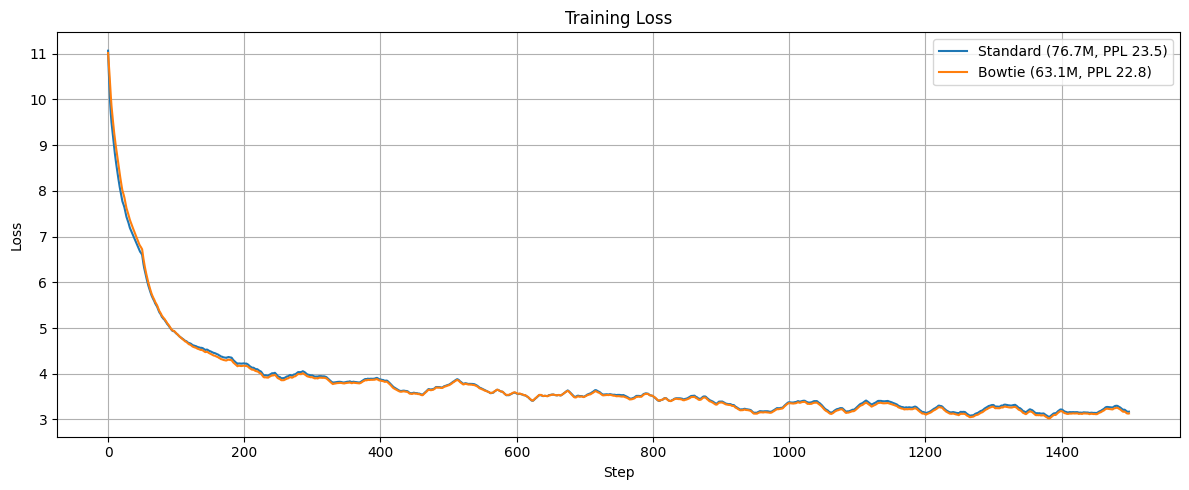


════════════════════════════════════════════════════════════
🏁 РЕЗУЛЬТАТЫ
════════════════════════════════════════════════════════════
Модель     | Параметры  | Слои   | Perplexity
------------------------------------------------------------
Standard   |     76.74M    | 8      |     23.48
Bowtie     |     63.11M    | 26     |     22.75
════════════════════════════════════════════════════════════
💾 Экономия параметров: 17.8%
✅ Качество сопоставимо — архитектура эффективна!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

💾 Сохранено: ./saved_models/standard_transformer/


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

💾 Сохранено: ./saved_models/bowtie_transformer/


Loading weights:   0%|          | 0/83 [00:00<?, ?it/s]

AttributeError: 'StandardTransformer' object has no attribute 'all_tied_weights_keys'

In [ ]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, IterableDataset
from transformers import (
    GPT2TokenizerFast,
    PretrainedConfig,
    PreTrainedModel,
)
from datasets import load_dataset
import matplotlib.pyplot as plt
import math
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="huggingface_hub")

# ==========================================
# 1. КОНФИГ
# ==========================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
D_MODEL = 512
MAX_SEQ_LEN = 128
BATCH_SIZE = 32
LR = 5e-4
TRAIN_STEPS = 1500
N_LAYERS = 8

tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token
VOCAB_SIZE = tokenizer.vocab_size

# ==========================================
# 2. АРХИТЕКТУРНЫЕ БЛОКИ
# ==========================================
class RMSNorm(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + 1e-6) * self.scale


class PreNormBlock(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        self.norm1 = RMSNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.norm2 = RMSNorm(dim)
        self.ffn   = nn.Sequential(
            nn.Linear(dim, dim * 4), nn.GELU(), nn.Linear(dim * 4, dim)
        )

    def forward(self, x):
        mask = torch.triu(torch.ones(x.size(1), x.size(1), device=x.device), 1).bool()
        attn_out, _ = self.attn(self.norm1(x), self.norm1(x), self.norm1(x),
                                attn_mask=mask, need_weights=False)
        x = x + attn_out
        x = x + self.ffn(self.norm2(x))
        return x


class ResidualAdapter(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.proj  = nn.Linear(d_in, d_out, bias=False)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        return self.gamma * self.proj(x)


# ==========================================
# 3. HuggingFace CONFIGS
# ==========================================
class StandardConfig(PretrainedConfig):
    model_type = "standard_transformer"

    def __init__(
        self,
        vocab_size: int = VOCAB_SIZE,
        d_model: int = D_MODEL,
        n_layers: int = N_LAYERS,
        max_seq_len: int = MAX_SEQ_LEN,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.vocab_size  = vocab_size
        self.d_model     = d_model
        self.n_layers    = n_layers
        self.max_seq_len = max_seq_len


class BowtieConfig(PretrainedConfig):
    model_type = "bowtie_transformer"

    def __init__(
        self,
        vocab_size: int = VOCAB_SIZE,
        d_model: int = D_MODEL,
        d_small: int = 256,
        n_layers: int = N_LAYERS,
        max_seq_len: int = MAX_SEQ_LEN,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.vocab_size  = vocab_size
        self.d_model     = d_model
        self.d_small     = d_small
        self.n_layers    = n_layers
        self.max_seq_len = max_seq_len


# ==========================================
# 4. HuggingFace МОДЕЛИ
# ==========================================
class StandardTransformer(PreTrainedModel):
    config_class = StandardConfig

    @classmethod
    def _can_set_experts_implementation(cls):
        return False

    def __init__(self, config: StandardConfig):
        super().__init__(config)
        d = config.d_model
        self.embed   = nn.Embedding(config.vocab_size, d)
        self.pos_emb = nn.Parameter(torch.randn(1, config.max_seq_len, d) * 0.02)
        self.layers  = nn.ModuleList(
            [PreNormBlock(d, 8) for _ in range(config.n_layers)]
        )
        self.head    = nn.Linear(d, config.vocab_size, bias=False)

    def forward(self, input_ids, **kwargs):
        x = self.embed(input_ids) + self.pos_emb[:, :input_ids.size(1), :]
        for layer in self.layers:
            x = layer(x)
        return self.head(x)


class BowtieTransformer(PreTrainedModel):
    config_class = BowtieConfig

    @classmethod
    def _can_set_experts_implementation(cls):
        return False

    def __init__(self, config: BowtieConfig):
        super().__init__(config)
        d, s = config.d_model, config.d_small
        self.embed        = nn.Embedding(config.vocab_size, d)
        self.pos_emb      = nn.Parameter(torch.randn(1, config.max_seq_len, d) * 0.02)
        self.layer_1      = PreNormBlock(d, 8)
        self.down_proj    = nn.Linear(d, s)
        self.entry_skip   = ResidualAdapter(d, s)
        n_mid             = config.n_layers - 2
        heads_small       = 8 if s % 8 == 0 else 1
        self.middle_layers = nn.ModuleList(
            [PreNormBlock(s, heads_small) for _ in range(n_mid)]
        )
        self.up_proj      = nn.Linear(s, d)
        self.global_skip  = ResidualAdapter(d, d)
        self.exit_skip    = ResidualAdapter(s, d)
        self.layer_L      = PreNormBlock(d, 8)
        self.head         = nn.Linear(d, config.vocab_size, bias=False)

    def forward(self, input_ids, **kwargs):
        x       = self.embed(input_ids) + self.pos_emb[:, :input_ids.size(1), :]
        h1      = self.layer_1(x)
        h_small = self.down_proj(h1) + self.entry_skip(h1)
        for layer in self.middle_layers:
            h_small = layer(h_small)
        h_big = self.up_proj(h_small) + self.global_skip(h1) + self.exit_skip(h_small)
        return self.head(self.layer_L(h_big))


# ==========================================
# 5. УТИЛИТЫ
# ==========================================
def compute_bowtie_config(d_model, compression_ratio=4, total_layers=26):
    """
    compression_ratio : во сколько раз d_small меньше d_model (4 → d_small=128)
    total_layers      : общее количество слоёв (26 = 2 big + 24 small)
    """
    d_small = (d_model // compression_ratio // 8) * 8  # кратно 8 для MultiheadAttention
    n_mid = total_layers - 2  # 26 - 2 = 24 малых слоя
    n_total = n_mid + 2

    # Эффективная глубина в эквиваленте больших слоёв
    big_in_small = (d_model / d_small) ** 2  # = 4² = 16
    effective_depth = 2 + n_mid / big_in_small

    # Оценка параметров (без учёта embed/head/skip)
    block_params = lambda d: 12 * d**2
    approx_params = 2 * block_params(d_model) + n_mid * block_params(d_small)

    print(f"📐 Конфигурация Bowtie:")
    print(f"   • d_small       = {d_small} (1/{compression_ratio} от {d_model})")
    print(f"   • n_layers      = {n_total} (2 big + {n_mid} small)")
    print(f"   • Эффективная глубина ≈ {effective_depth:.1f} больших слоёв")
    print(f"   • ~{approx_params/1e6:.1f}M параметров в трансформер-блоках")

    return d_small, n_total


class TinyStoriesIterable(IterableDataset):
    def __init__(self, dataset, tokenizer, max_len):
        self.dataset = dataset
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __iter__(self):
        for ex in self.dataset:
            ids = self.tokenizer.encode(
                ex["text"], truncation=True,
                max_length=self.max_len, padding="max_length"
            )
            yield torch.tensor(ids)


def train_model(model, name):
    print(f"\n🔄 Обучение: {name}")
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))
    losses = []
    model.train()
    step = 0

    for batch in loader:
        x = batch.to(DEVICE)
        with torch.amp.autocast("cuda", enabled=(DEVICE == "cuda")):
            logits = model(x)
            loss = F.cross_entropy(
                logits[:, :-1, :].reshape(-1, VOCAB_SIZE),
                x[:, 1:].reshape(-1),
                ignore_index=tokenizer.pad_token_id,
            )
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        losses.append(loss.item())

        if step % 100 == 0:
            ppl = math.exp(min(loss.item(), 10))  # защита от overflow
            print(f"  Step {step:4d}/{TRAIN_STEPS} | Loss: {loss.item():.4f} | PPL: {ppl:.2f}")
        step += 1
        if step >= TRAIN_STEPS:
            break

    # Финальная метрика
    avg_loss = sum(losses[-100:]) / min(100, len(losses))
    final_ppl = math.exp(min(avg_loss, 10))
    print(f"  ✅ Finish | Avg Loss: {avg_loss:.4f} | 🎯 PPL: {final_ppl:.2f}")

    return losses, sum(p.numel() for p in model.parameters()), final_ppl


# ==========================================
# 6. ИНИЦИАЛИЗАЦИЯ
# ==========================================
# 🔹 26 слоёв при коэффициенте сжатия 4
D_SMALL, N_LAYERS_BOW = compute_bowtie_config(
    d_model=D_MODEL,
    compression_ratio=4,   # d_small = 128
    total_layers=26        # ← ровно 26: 2 больших + 24 малых
)

std_cfg = StandardConfig()
m_std = StandardTransformer(std_cfg)
bow_cfg = BowtieConfig(d_small=D_SMALL, n_layers=N_LAYERS_BOW)
m_bow = BowtieTransformer(bow_cfg)

p_std = sum(p.numel() for p in m_std.parameters())
p_bow = sum(p.numel() for p in m_bow.parameters())
print(f"\n📊 Standard: {p_std/1e6:.2f}M параметров | {N_LAYERS} слоёв")
print(f"📊 Bowtie:   {p_bow/1e6:.2f}M параметров | {N_LAYERS_BOW} слоёв (d_small={D_SMALL})")

raw_dataset = load_dataset("roneneldan/TinyStories", split="train", streaming=True)
iterable_ds = TinyStoriesIterable(raw_dataset, tokenizer, MAX_SEQ_LEN)
loader = DataLoader(iterable_ds, batch_size=BATCH_SIZE)

# ==========================================
# 7. ОБУЧЕНИЕ
# ==========================================
loss_std, p1, ppl_std = train_model(m_std, "Standard")
loss_bow, p2, ppl_bow = train_model(m_bow, "Bowtie")

# ==========================================
# 8. ГРАФИК
# ==========================================
def smooth(x, w=50):
    return [sum(x[max(0, i-w):i+1]) / len(x[max(0, i-w):i+1]) for i in range(len(x))]

plt.figure(figsize=(12, 5))
plt.plot(smooth(loss_std), label=f"Standard ({p1/1e6:.1f}M, PPL {ppl_std:.1f})")
plt.plot(smooth(loss_bow), label=f"Bowtie ({p2/1e6:.1f}M, PPL {ppl_bow:.1f})")
plt.legend(); plt.grid(True); plt.title("Training Loss"); plt.xlabel("Step"); plt.ylabel("Loss")
plt.tight_layout(); plt.show()

# ==========================================
# 9. ФИНАЛЬНЫЙ ОТЧЁТ
# ==========================================
print("\n" + "═"*60)
print("🏁 РЕЗУЛЬТАТЫ")
print("═"*60)
print(f"{'Модель':<10} | {'Параметры':<10} | {'Слои':<6} | {'Perplexity':<10}")
print("-"*60)
print(f"{'Standard':<10} | {p1/1e6:>9.2f}M    | {N_LAYERS:<6} | {ppl_std:>9.2f}")
print(f"{'Bowtie':<10} | {p2/1e6:>9.2f}M    | {N_LAYERS_BOW:<6} | {ppl_bow:>9.2f}")
print("═"*60)

# Экономия параметров
saving = (1 - p2/p1) * 100
print(f"💾 Экономия параметров: {saving:.1f}%")
if ppl_bow <= ppl_std * 1.15:
    print("✅ Качество сопоставимо — архитектура эффективна!")
else:
    print("⚠️ Perplexity выше — попробуйте уменьшить compression_ratio до 2")

# ==========================================
# 10. СОХРАНЕНИЕ
# ==========================================
SAVE_DIR = "./saved_models"
for name, model in [("standard_transformer", m_std), ("bowtie_transformer", m_bow)]:
    out = os.path.join(SAVE_DIR, name)
    model.save_pretrained(out)
    tokenizer.save_pretrained(out)
    print(f"💾 Сохранено: {out}/")

# ==========================================
# 11. ПРОВЕРКА ЗАГРУЗКИ
# ==========================================
from transformers import AutoModel
StandardConfig.register_for_auto_class()
StandardTransformer.register_for_auto_class("AutoModel")
BowtieConfig.register_for_auto_class()
BowtieTransformer.register_for_auto_class("AutoModel")

loaded_std = StandardTransformer.from_pretrained(f"{SAVE_DIR}/standard_transformer")
loaded_bow = BowtieTransformer.from_pretrained(f"{SAVE_DIR}/bowtie_transformer")
print("✅ Модели загружены успешно ✓")